## 1-3.a
$\sigma_x =  \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} $

$\sigma_y =  \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} $

$\sigma_z =  \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} $

$I =  \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} $

Thus outer products:

$\sigma_x = \ket{0}\bra{1} + \ket{1}\bra{0}$

$\sigma_y = -i\ket{0}\bra{1} + i\ket{1}\bra{0}$

$\sigma_z = -\ket{1}\bra{1} + \ket{0}\bra{0}$

$I = \ket{1}\bra{1} + \ket{0}\bra{0}$


## b

Handwritten segment:
![Screenshot 2026-03-31 231851.png](<attachment:Screenshot 2026-03-31 231851.png>) ![Screenshot 2026-03-31 231933.png](<attachment:Screenshot 2026-03-31 231933.png>) ![Screenshot 2026-03-31 231954.png](<attachment:Screenshot 2026-03-31 231954.png>) ![Screenshot 2026-03-31 232013.png](<attachment:Screenshot 2026-03-31 232013.png>) ![Screenshot 2026-03-31 232038.png](<attachment:Screenshot 2026-03-31 232038.png>)
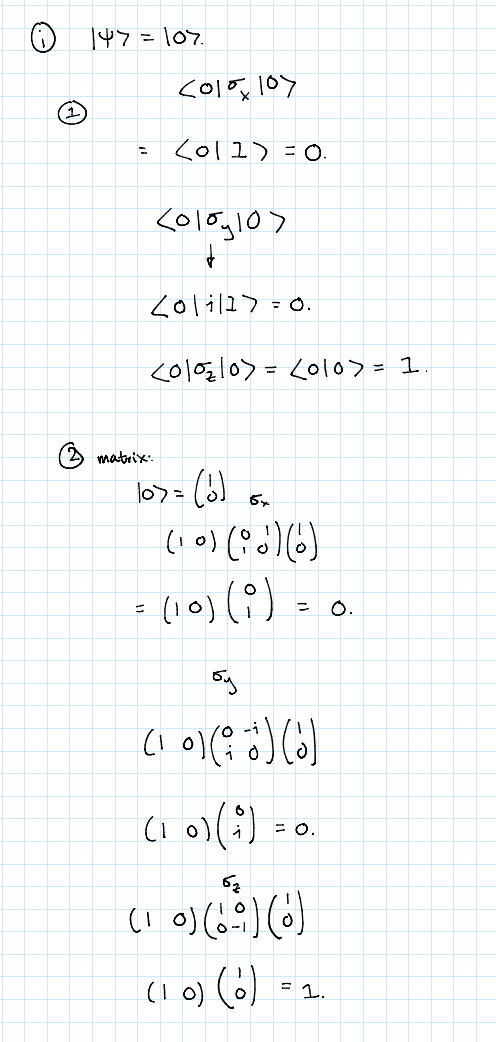
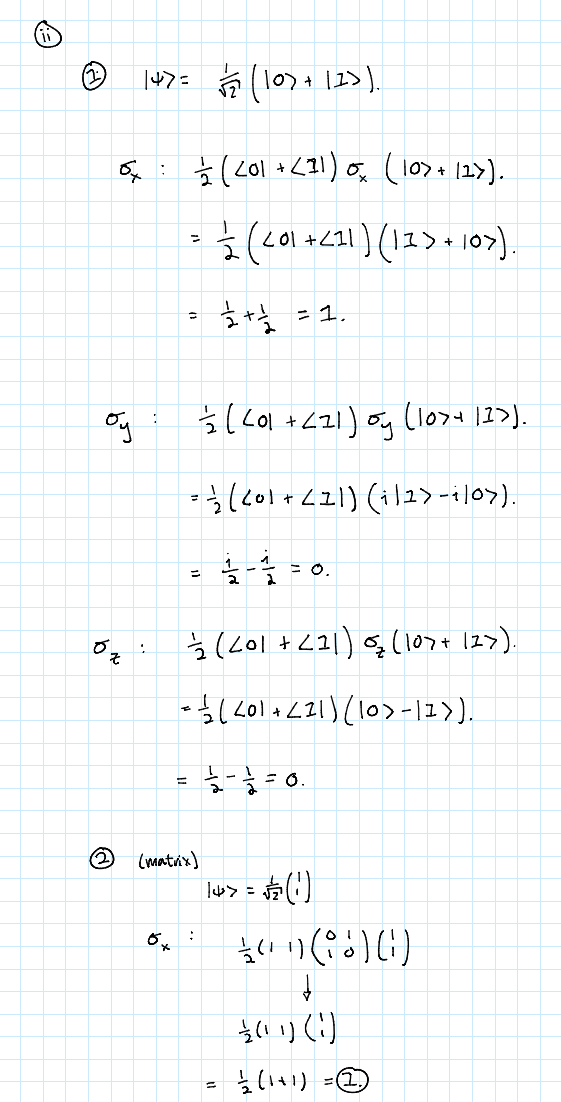
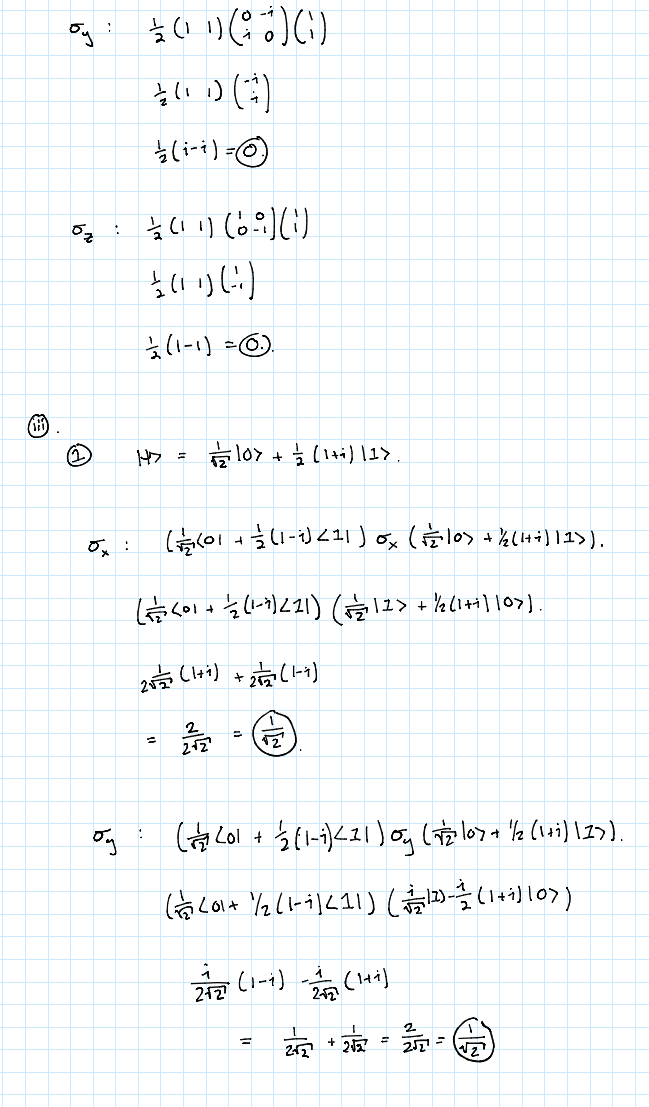
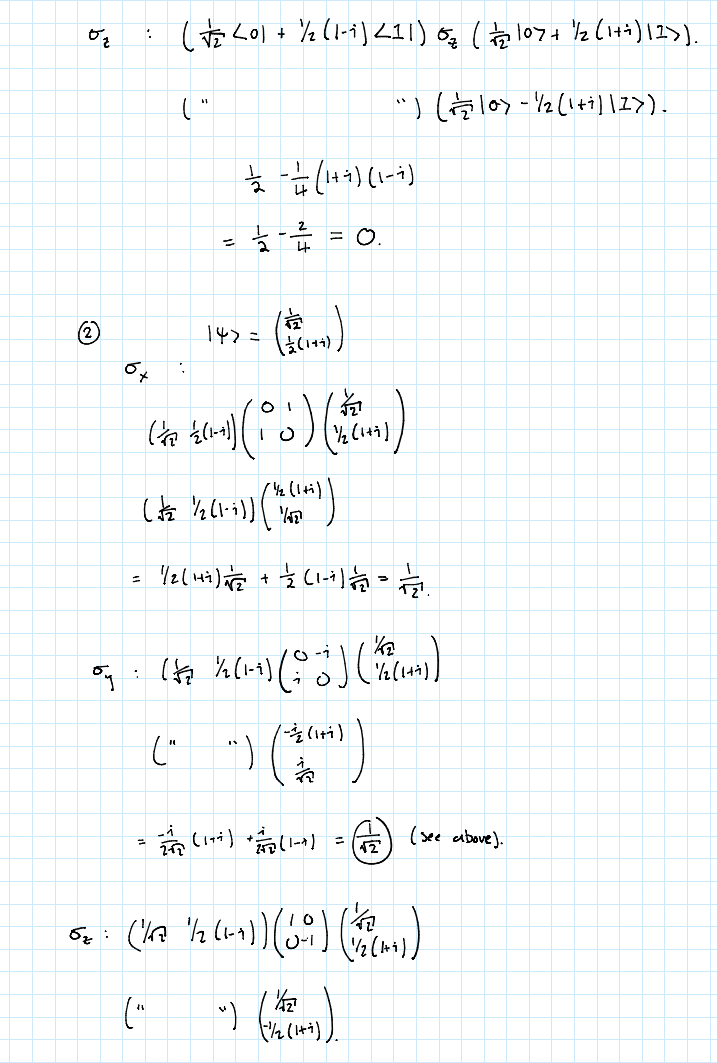
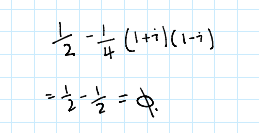

Qutip section:

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import basis, sigmay, sigmax, sigmaz, expect

In [3]:
# Define kets
ket1 = basis(2, 0)
ket2 = (basis(2, 0) + basis(2, 1)).unit()
ket3 = 1/np.sqrt(2) * basis(2, 0) + 0.5*(1+1j) * basis(2, 1)

kets = [ket1, ket2, ket3]

### Note that below ordering is in order of example, and then in order of X, Y, Z

In [4]:
sigma_vec = np.array(
    [sigmax(), sigmay(), sigmaz()]
)
for ket in kets:
    for sigma in sigma_vec:
        print(f"{expect(sigma, ket)}")

0.0
0.0
1.0
0.9999999999999998
0.0
0.0
0.7071067811865475
0.7071067811865475
-1.1102230246251565e-16


Thus we see that these values match our analytical calculations down to floating point (0.7071 ~ $1/sqrt(2)$)

# c

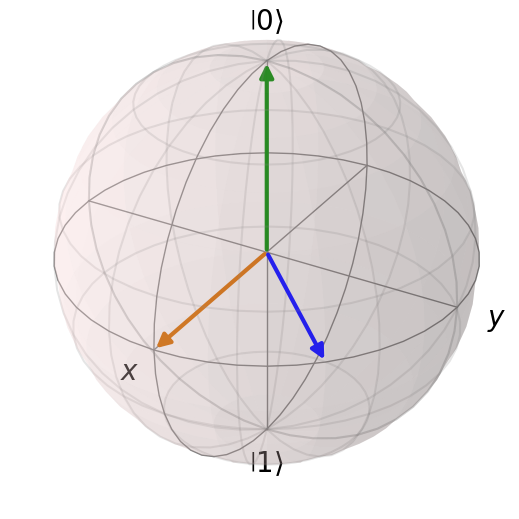

In [32]:
b = qutip.Bloch()
b.add_states(kets)

b.show()

# d

![Screenshot 2026-03-31 232109.png](<attachment:Screenshot 2026-03-31 232109.png>)
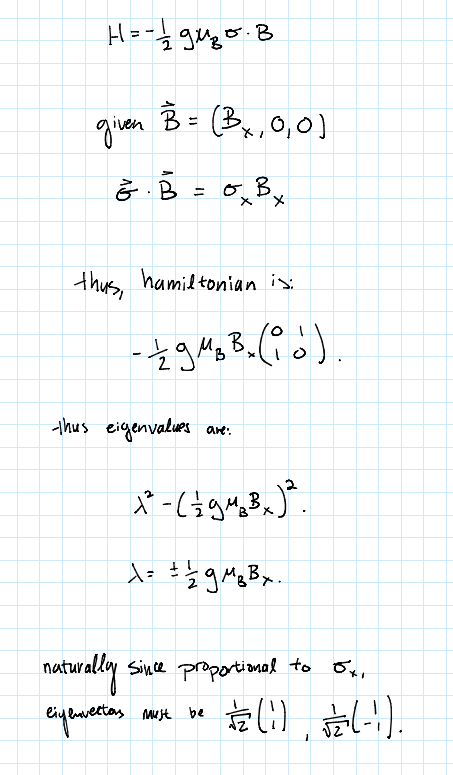

## e

In [21]:
g = 2
mu_b = 1.4
B_x = 200

A = -0.5*g*mu_b*B_x

H = A * sigmax()

evals, estates = H.eigenstates()

print(f"Hamiltonian in MHz:")
display(H)
print(f"Eigenvalues in MHz: {evals}")
print(f"Eigenvectors:")
for e in estates:
    display(e)

Hamiltonian in MHz:


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[   0. -280.]
 [-280.    0.]]

Eigenvalues in MHz: [-280.  280.]
Eigenvectors:


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70710678]
 [-0.70710678]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70710678]
 [ 0.70710678]]

## f

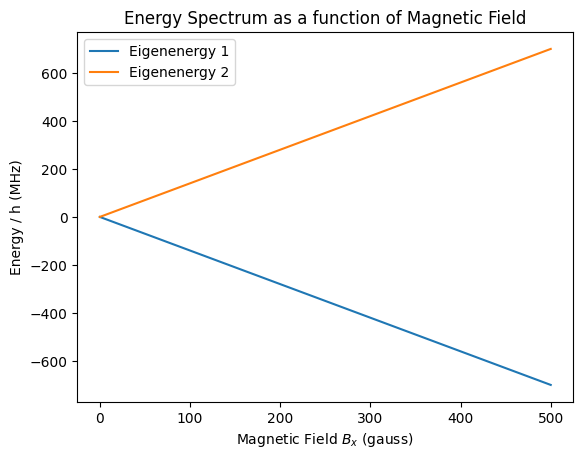

In [30]:
field_range = np.linspace(0, 500, 1000)

# should always be two eigenstates
evals_1 = []
evals_2 = []

for B_x in field_range:
    H = -0.5 * g * mu_b * B_x * sigmax()

    evals = H.eigenenergies()
    evals_1.append(evals[0])
    evals_2.append(evals[1])

fig, ax = plt.subplots()

ax.plot(field_range, evals_1, label="Eigenenergy 1")
ax.plot(field_range, evals_2, label="Eigenenergy 2")

plt.xlabel('Magnetic Field $B_x$ (gauss)')
plt.ylabel('Energy / h (MHz)')
plt.title("Energy Spectrum as a function of Magnetic Field")
plt.legend();
